In [1]:
import numpy as np
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql+psycopg2://berdefizita@localhost:5432/twitter_cities_test"
)
from sqlalchemy import text

I. TABLES

Creation of `tweet_places` table:

* supplement missing tweet coordinates from the `place` table
* keep only place centroids with acceptable spatial error (`err < 200`)
* combine tweets with original coordinates and tweets with place-based coordinates
* create one located tweet-level table
* generate H3 hexagons at resolutions 8, 9 and 10

In [ ]:
# runtime: 148m
with engine.begin() as conn:
    conn.execute(text("drop table if exists tweet_places;"))
    conn.execute(text("""create extension if not exists h3_postgis"""))
    conn.execute(text(
    """create table tweet_places as
select city
     , tweet_id
     , user_id
     , place_id
     , created_at
     , lat
     , lon
     , h3_lat_lng_to_cell(point(lon, lat), 10) as h3_10
     , h3_lat_lng_to_cell(point(lon, lat), 9)  as h3_9
     , h3_lat_lng_to_cell(point(lon, lat), 8)  as h3_8
from tweet
where lat is not null
  and lon is not null

union all

select city
     , tweet_id
     , user_id
     , a.place_id
     , created_at
     , b.centroid_lat as lat
     , b.centroid_lon as lon
     , h3_lat_lng_to_cell(point(b.centroid_lon, b.centroid_lat), 10) as h3_10
     , h3_lat_lng_to_cell(point(b.centroid_lon, b.centroid_lat), 9)  as h3_9
     , h3_lat_lng_to_cell(point(b.centroid_lon, b.centroid_lat), 8)  as h3_8
from tweet a
inner join place b on a.place_id = b.place_id
where (a.lat is null or a.lon is null)
  and b.err < 200"""
    ))

Creation of `tweet_limit` table:

* create `tweet_limit_tmp` with users who have at least 50 located tweets
* keep only tweets with valid coordinates
* restrict data to the 2014–2016 period
* create `tweet_limit` with all tweets from these selected users
* final table contains only active users with valid located tweet

In [ ]:
# runtime: 2m
with engine.begin() as conn:
    conn.execute(text("drop table if exists tweet_limit_tmp;"))
    conn.execute(text(
    """create table tweet_limit_tmp as
       select user_id
            , count(distinct tweet_id) cnt
       from tweet_places
       where lat is not null 
         and lon is not null 
         and date_trunc('year',created_at) between date'2014-01-01' and date'2016-01-01'
       group by user_id 
       having count(distinct tweet_id) >= 50"""
    ))
    
    conn.execute(text("drop table if exists tweet_limit;"))
    conn.execute(text(
    """create table tweet_limit as
       select *
       from tweet_places
       where user_id in (select user_id from tweet_limit_tmp)
       and lat is not null
       and lon is not null
       and date_trunc('year',created_at) between date'2014-01-01' and date'2016-01-01'"""
    ))

Creation of `tweet_places_bbox` table:

* create bounding boxes for London, Portland and Amsterdam
* define each city by minimum and maximum latitude/longitude
* join tweet locations to city bounding boxes
* assign `city_bbox` based on whether coordinates fall inside a city boundary
* keep all tweets, even if they do not fall into any bounding box


In [ ]:
# runtime: 2m
with engine.begin() as conn:

# City Bounding Box table
    conn.execute(text("drop table if exists city_bbox;"))
    conn.execute(text(
    """create table city_bbox (city text, lat_min double precision, lat_max double precision, lon_min double precision,lon_max double precision);"""))
    
    # London
    conn.execute(text(
    """insert into city_bbox values ('london', 51.2867601, 51.6918741, -0.5103751, 0.3340155);"""))
    
    # Portland
    conn.execute(text(
    """insert into city_bbox values ('portland', 45.4325360, 45.6528812, -122.8367489, -122.4720252);"""))

    # Amsterdam
    conn.execute(text(
    """insert into city_bbox values ('amsterdam', 52.2781742, 52.4310638, 4.7287776, 5.0791622);"""))

# tweet_places with city bbox column
    conn.execute(text("drop table if exists tweet_places_bbox;"))
    conn.execute(text(
        """create table tweet_places_bbox as
            select a.*, b.city as city_bbox
            from tweet_places a
             left join city_bbox b on a.lat between b.lat_min and b.lat_max and a.lon between b.lon_min and b.lon_max;"""))

Creation of `tweet_2013_2017_min20` table:

* keep tweets from London, Portland and Amsterdam only
* restrict data to the 2013–2017 period
* keep only records with valid coordinates
* select users with at least 20 located tweets
* create final tweet table for these selected users

In [ ]:
# runtime: 2m
with engine.begin() as conn:

# only records with valid coordinates
# time period is 2013-2017
# only users with >= 20 tweet
    conn.execute(text("drop table if exists tweet_limit_2013_2017_min20_tmp;"))
    conn.execute(text(
    """create table tweet_limit_2013_2017_min20_tmp as
       select user_id
            , count(distinct tweet_id) cnt
       from tweet_places_bbox 
       where lat is not null 
         and lon is not null
         and date_trunc('year',created_at) between date'2013-01-01' and date'2017-01-01'
         and city_bbox in ('london','portland','amsterdam')
       group by user_id 
       having count(distinct tweet_id) >= 20"""))

# only users from tweet_2013_2017_min20_tmp table
# valid coordinates
# time period is 2013-2017
    conn.execute(text("drop table if exists tweet_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_2013_2017_min20 as
       select *
       from tweet_places_bbox
       where user_id in (select user_id from tweet_limit_2013_2017_min20_tmp)
       and lat is not null
       and lon is not null
       and city_bbox in ('london','portland','amsterdam')
       and date_trunc('year',created_at) between date'2013-01-01' and date'2017-01-01'"""))

Home location detection based on night-time tweeting activity:

* filter tweets to home hours: 20:00–08:00
* count all home-hour tweets per user
* count all tweets per user and H3 hexagon
* count home-hour tweets per user and H3 hexagon
* keep hexagons with at least 2 home-hour tweets
* calculate home-hour tweet ratio for each hexagon
* select the top home-location candidate per user
* repeat the process for H3 resolutions 10, 9 and 8
* flag whether each tweet falls into the user's selected home hexagon
* create final `homelocation` table with tweet-level home-location indicators

In [ ]:
# runtime: 9.5m
with engine.begin() as conn:

# home-hours 20:00-8:00  
    conn.execute(text("drop table if exists tweet_utc820_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_utc820_2013_2017_min20 as
        select *
        from tweet_2013_2017_min20
        where extract(hour from created_at) < 8
        or extract(hour from created_at) >= 20"""))
    
# all tweet home-hours 20:00-8:00  
    conn.execute(text("drop table if exists all_tweet_utc820_2013_2017_min20;"))
    conn.execute(text(
    """create table all_tweet_utc820_2013_2017_min20 as
        select user_id, count(tweet_id) homehour_tweet_cnt
        from tweet_2013_2017_min20
        where extract(hour from created_at) < 8
        or extract(hour from created_at) >= 20
        group by user_id"""))

# all tweet count per hexagon sizes
    # size 10
    conn.execute(text("drop table if exists tweet_all_s10_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_all_s10_2013_2017_min20 as
       select user_id, h3_10, count(tweet_id) as tweet_all_s10_cnt
        from tweet_2013_2017_min20 group by user_id, h3_10"""))
    
    # size 9
    conn.execute(text("drop table if exists tweet_all_s9_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_all_s9_2013_2017_min20 as
       select user_id, h3_9, count(tweet_id) as tweet_all_s9_cnt
        from tweet_2013_2017_min20 group by user_id, h3_9"""))
    
    # size 8
    conn.execute(text("drop table if exists tweet_all_s8_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_all_s8_2013_2017_min20 as
       select user_id, h3_8, count(tweet_id) as tweet_all_s8_cnt
        from tweet_2013_2017_min20 group by user_id, h3_8"""))
    
# home-hours tweet count per hexagon sizes
# min 2 tweets in that period

    # size 10
    conn.execute(text("drop table if exists tweet_s10_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_s10_2013_2017_min20 as
       select user_id, h3_10, count(tweet_id) as tweet_utc820_s10_cnt
        from tweet_utc820_2013_2017_min20
        group by user_id, h3_10
        having count(tweet_id) >= 2"""))
    
    # size 9
    conn.execute(text("drop table if exists tweet_s9_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_s9_2013_2017_min20 as
       select user_id, h3_9, count(tweet_id) as tweet_utc820_s9_cnt
        from tweet_utc820_2013_2017_min20 
        group by user_id, h3_9
        having count(tweet_id) >= 2"""))
    
    # size 8
    conn.execute(text("drop table if exists tweet_s8_2013_2017_min20;"))
    conn.execute(text(
    """create table tweet_s8_2013_2017_min20 as
       select user_id, h3_8, count(tweet_id) as tweet_utc820_s8_cnt
        from tweet_utc820_2013_2017_min20 
        group by user_id, h3_8
        having count(tweet_id) >= 2"""))
    
    # ratios and order per hexagon sizes

    # size 10
    conn.execute(text("drop table if exists s10_tmp;"))
    conn.execute(text("""
        create table s10_tmp as
        select user_id, h3_10, tweet_utc820_s10_cnt, tweet_all_s10_cnt, tweet_ratio
        from (select *, row_number() over (partition by user_id order by tweet_ratio desc, tweet_all_s10_cnt desc) as rn
        from (select a.*,
                     b.tweet_utc820_s10_cnt,
                     coalesce(b.tweet_utc820_s10_cnt, 0)::numeric / a.tweet_all_s10_cnt as tweet_ratio
                from tweet_all_s10_2013_2017_min20 a
                left join tweet_s10_2013_2017_min20 b on a.user_id = b.user_id and a.h3_10 = b.h3_10) a) b
        where rn = 1"""))

    # size 9
    conn.execute(text("drop table if exists s9_tmp;"))
    conn.execute(text("""
        create table s9_tmp as
        select user_id, h3_9, tweet_utc820_s9_cnt, tweet_all_s9_cnt, tweet_ratio
        from (select *, row_number() over (partition by user_id order by tweet_ratio desc, tweet_all_s9_cnt desc) as rn
        from (select a.*,
                     b.tweet_utc820_s9_cnt,
                     coalesce(b.tweet_utc820_s9_cnt, 0)::numeric / a.tweet_all_s9_cnt as tweet_ratio
                from tweet_all_s9_2013_2017_min20 a
                left join tweet_s9_2013_2017_min20 b on a.user_id = b.user_id and a.h3_9 = b.h3_9) a) b
        where rn = 1"""))

    # size 8
    conn.execute(text("drop table if exists s8_tmp;"))
    conn.execute(text("""
        create table s8_tmp as
        select user_id, h3_8, tweet_utc820_s8_cnt, tweet_all_s8_cnt, tweet_ratio
        from (select *, row_number() over (partition by user_id order by tweet_ratio desc, tweet_all_s8_cnt desc) as rn
        from (select a.*,
                     b.tweet_utc820_s8_cnt,
                     coalesce(b.tweet_utc820_s8_cnt, 0)::numeric / a.tweet_all_s8_cnt as tweet_ratio
                from tweet_all_s8_2013_2017_min20 a
                left join tweet_s8_2013_2017_min20 b on a.user_id = b.user_id and a.h3_8 = b.h3_8) a) b
        where rn = 1"""))

# home location and tweet count per user per hexagon sizes

    # size 10
    conn.execute(text("drop table if exists tweet_count_s10;"))
    conn.execute(text("""
        create table tweet_count_s10 as
        select distinct a.user_id
                      , city_bbox
                      , a.h3_10
                      , e.tweet_all_s10_cnt
                      , b.tweet_utc820_s10_cnt
                      , case when b.tweet_utc820_s10_cnt is not null then 'Y' else 'N' end homelocation_h3_10
        from tweet_2013_2017_min20 a
        left join s10_tmp b on a.user_id = b.user_id and a.h3_10 = b.h3_10
        left join tweet_all_s10_2013_2017_min20 e on a.user_id = e.user_id and a.h3_10 = e.h3_10"""))

    # size 9
    conn.execute(text("drop table if exists tweet_count_s9;"))
    conn.execute(text("""
        create table tweet_count_s9 as
        select distinct a.user_id
                      , city_bbox
                      , a.h3_9
                      , e.tweet_all_s9_cnt
                      , b.tweet_utc820_s9_cnt
                      , case when b.tweet_utc820_s9_cnt is not null then 'Y' else 'N' end homelocation_h3_9
        from tweet_2013_2017_min20 a
        left join s9_tmp b on a.user_id = b.user_id and a.h3_9 = b.h3_9
        left join tweet_all_s9_2013_2017_min20 e on a.user_id = e.user_id and a.h3_9 = e.h3_9"""))
    
    # size 8
    conn.execute(text("drop table if exists tweet_count_s8;"))
    conn.execute(text("""
        create table tweet_count_s8 as
        select distinct a.user_id
                      , city_bbox
                      , a.h3_8
                      , e.tweet_all_s8_cnt
                      , b.tweet_utc820_s8_cnt
                      , case when b.tweet_utc820_s8_cnt is not null then 'Y' else 'N' end homelocation_h3_8
        from tweet_2013_2017_min20 a
        left join s8_tmp b on a.user_id = b.user_id and a.h3_8 = b.h3_8
        left join tweet_all_s8_2013_2017_min20 e on a.user_id = e.user_id and a.h3_8 = e.h3_8"""))

# all geo located tweet with hexagons and home location infos
    conn.execute(text("drop table if exists homelocation;"))
    conn.execute(text("""
        create table homelocation as
        select distinct a.*
                      , e.tweet_all_s10_cnt
                      , b.tweet_utc820_s10_cnt
                      , case when b.tweet_utc820_s10_cnt is not null then 'Y' else 'N' end homelocation_h3_10
                      , f.tweet_all_s9_cnt
                      , c.tweet_utc820_s9_cnt
                      , case when c.tweet_utc820_s9_cnt is not null then 'Y' else 'N' end homelocation_h3_9
                      , g.tweet_all_s8_cnt
                      , d.tweet_utc820_s8_cnt
                      , case when d.tweet_utc820_s8_cnt is not null then 'Y' else 'N' end homelocation_h3_8
        from tweet_2013_2017_min20 a
        left join s10_tmp b on a.user_id = b.user_id and a.h3_10 = b.h3_10
        left join s9_tmp c on a.user_id = c.user_id and a.h3_9 = c.h3_9
        left join s8_tmp d on a.user_id = d.user_id and a.h3_8 = d.h3_8
        left join tweet_all_s10_2013_2017_min20 e on a.user_id = e.user_id and a.h3_10 = e.h3_10
        left join tweet_all_s9_2013_2017_min20 f on a.user_id = f.user_id and a.h3_9 = f.h3_9
        left join tweet_all_s8_2013_2017_min20 g on a.user_id = g.user_id and a.h3_8 = g.h3_8"""))

II. DESCRIPTIVE ANALYSIS

Basic city-level summary:

* load tweets located in London, Amsterdam and Portland
* group records by city
* count unique users per city
* count total tweets per city
* compare dataset size across cities

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# runtime: 11m
df = pd.read_sql("""select * from tweet_places_bbox where city_bbox in ('london','amsterdam','portland')""",engine)
res = (
    df
    .groupby(["city_bbox"], as_index=False)
    .agg(
        user_cnt=("user_id", "nunique"),
        tweet_cnt=("tweet_id", "count")
    )
)
res

,city_bbox,user_cnt,tweet_cnt
0,amsterdam,296934,3750338
1,london,1104743,39226270
2,portland,170118,6955992


Figure: Number of users by city

* bar chart of unique users by city
* cities are shown in fixed order: London, Amsterdam, Portland
* each city has a separate color
* used to compare sample size across cities

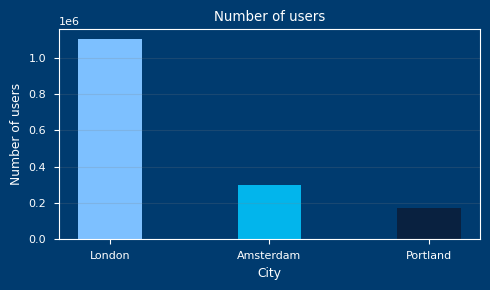

In [5]:
plt.style.use("seaborn-v0_8-paper")

city_order = ["london","amsterdam", "portland"]

plot_data = (
    res
    .set_index("city_bbox")
    .loc[city_order]
    .reset_index()
)

city_colors = {
    "london": "#7DC0FF",
    "amsterdam": "#02b5ec",
    "portland": "#092140"
}

fig, ax = plt.subplots(figsize=(5, 3))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

ax.bar(
    plot_data["city_bbox"].str.capitalize(),
    plot_data["user_cnt"],
    color=[city_colors[city] for city in plot_data["city_bbox"]],
    width=0.4
)

ax.set_title(
    "Number of users",
    color="white"
)

ax.set_xlabel("City", color="white")
ax.set_ylabel("Number of users", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", color="grey", alpha=0.2)
ax.grid(axis="x", visible=False)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Number of tweets by city

* bar chart of total tweets by city
* cities are shown in fixed order: London, Amsterdam, Portland
* used to compare tweet volume across cities

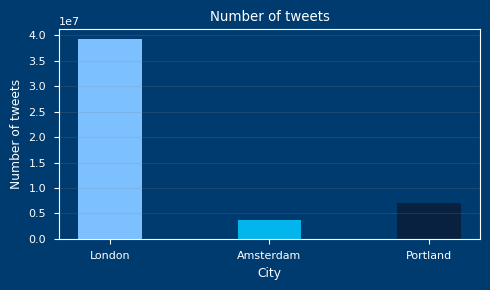

In [6]:
plt.style.use("seaborn-v0_8-paper")

city_order = ["london","amsterdam", "portland"]

plot_data = (
    res
    .set_index("city_bbox")
    .loc[city_order]
    .reset_index()
)

city_colors = {
    "london": "#7DC0FF",
    "amsterdam": "#02b5ec",
    "portland": "#092140"
}

fig, ax = plt.subplots(figsize=(5, 3))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

ax.bar(
    plot_data["city_bbox"].str.capitalize(),
    plot_data["tweet_cnt"],
    color=[city_colors[city] for city in plot_data["city_bbox"]],
    width=0.4
)

ax.set_title(
    "Number of tweets",
    color="white"
)

ax.set_xlabel("City", color="white")
ax.set_ylabel("Number of tweets", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", color="grey", alpha=0.2)
ax.grid(axis="x", visible=False)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Yearly number of tweets by city

* line chart of yearly tweet counts by city
* shows temporal trends in tweet activity
* compares London, Amsterdam and Portland over time
* separate line for each city

In [7]:
result = (
    df
    .assign(years=pd.to_datetime(df["created_at"]).dt.year)
    .groupby(["city_bbox", "years"], as_index=False)
    .agg(
        user_cnt=("user_id", "nunique"),
        tweet_cnt=("tweet_id", "count")
    )
)

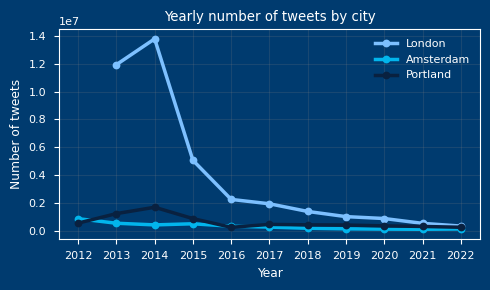

In [8]:
plt.style.use("seaborn-v0_8-paper")
city_data = (
    result[result["city_bbox"].isin(["london", "amsterdam", "portland"])]
    .copy()
    .sort_values(["city_bbox", "years"])
)

fig, ax = plt.subplots(figsize=(5, 3))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

city_colors = {
    "london": "#7DC0FF",
    "amsterdam": "#02b5ec",
    "portland": "#092140"
}

for city in ["london", "amsterdam", "portland"]:
    one_city = city_data[city_data["city_bbox"] == city]
    
    ax.plot(
        one_city["years"],
        one_city["tweet_cnt"],
        marker="o",
        color=city_colors[city],
        linewidth=2.5,
        label=city.capitalize()
    )

ax.set_title("Yearly number of tweets by city", color="white")
ax.set_xlabel("Year", color="white")
ax.set_ylabel("Number of tweets", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.set_xticks(sorted(city_data["years"].unique()))

legend = ax.legend()
for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")

ax.grid(color="grey", alpha=0.2)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Yearly number of users by city

* line chart of yearly unique user counts by city
* compares user activity over time in London, Amsterdam and Portland
* separate line for each city

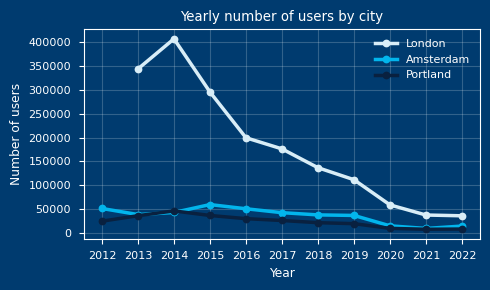

In [9]:
plt.style.use("seaborn-v0_8-paper")

city_data = (
    result[result["city_bbox"].isin(["london", "amsterdam", "portland"])]
    .copy()
    .sort_values(["city_bbox", "years"])
)

fig, ax = plt.subplots(figsize=(5, 3))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

city_colors = {
    "london": "#D8EDF7",
    "amsterdam": "#02b5ec",
    "portland": "#092140"
}

for city in ["london", "amsterdam", "portland"]:
    one_city = city_data[city_data["city_bbox"] == city]
    
    ax.plot(
        one_city["years"],
        one_city["user_cnt"],
        marker="o",
        color=city_colors[city],
        linewidth=2.5,
        label=city.capitalize()
    )

ax.set_title("Yearly number of users by city", color="white")
ax.set_xlabel("Year", color="white")
ax.set_ylabel("Number of users", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.set_xticks(sorted(city_data["years"].unique()))

legend = ax.legend()
for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")

ax.grid(color="white", alpha=0.2)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Place type data preparation:

* load tweets located inside London, Amsterdam and Portland
* join tweet records with the `place` table
* add `place_type` to each tweet
* keep only tweets with a matching `place_id`
* prepare data for place type analysis

In [10]:
# runtime: 3m
# nr places ONLY inside London, Amsterdam, Portland 
df2 = pd.read_sql("""select a.*, b.place_type
                  from tweet_places_bbox a
                  inner join place b on a.place_id = b.place_id
                  where city_bbox in ('london','amsterdam','portland')""",engine)

Number of places by city

* count unique places inside each city
* group places by city
* bar chart of place counts
* compare spatial coverage across cities

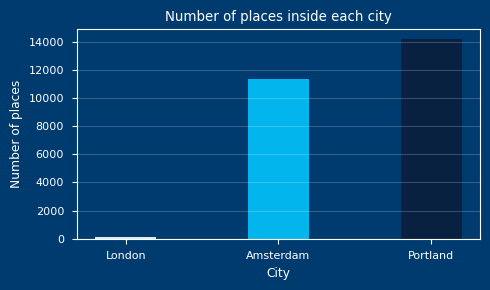

In [11]:
result_places_city = (
    df2
    .groupby("city_bbox", as_index=False)
    .agg(
        place_cnt=("place_id", "nunique")
    )
)

plt.style.use("seaborn-v0_8-paper")

city_order = ["london","amsterdam", "portland"]

plot_data = (
    result_places_city
    .set_index("city_bbox")
    .loc[city_order]
    .reset_index()
)

city_colors = {
    "london": "#D8EDF7",
    "amsterdam": "#02b5ec",
    "portland": "#092140"
}

fig, ax = plt.subplots(figsize=(5, 3))

# háttér
fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

# oszlopdiagram
ax.bar(
    plot_data["city_bbox"].str.capitalize(),
    plot_data["place_cnt"],
    color=[city_colors[city] for city in plot_data["city_bbox"]],
    width=0.4
)

# címek
ax.set_title(
    "Number of places inside each city",
    color="white"
)

ax.set_xlabel("City", color="white")
ax.set_ylabel("Number of places", color="white")

# tengelyfeliratok fehéren
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# rács
ax.grid(axis="y", color="white", alpha=0.2)
ax.grid(axis="x", visible=False)

# keret
for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Number of places by place type and city

* count unique places by place_type and city
* compare place type composition across London, Amsterdam and Portland
* grouped bar chart by place type
* different colors represent the three cities

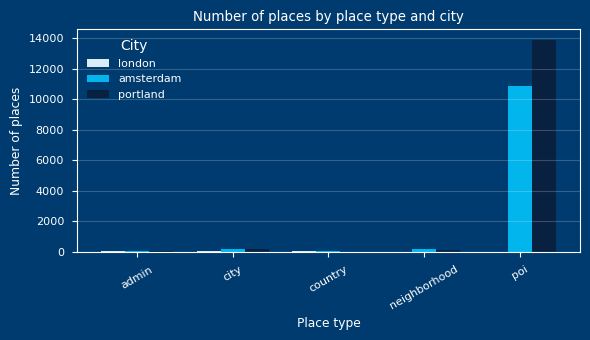

In [12]:
plt.style.use("seaborn-v0_8-paper")

result_places_type_city = (
    df2
    .groupby(["place_type", "city_bbox"], as_index=False)
    .agg(place_cnt=("place_id", "nunique"))
)

plot_data = (
    result_places_type_city
    .pivot(index="place_type", columns="city_bbox", values="place_cnt")
    .fillna(0)
)

plot_data = plot_data[["london", "amsterdam", "portland"]]

city_colors = {
    "london": "#D8EDF7",
    "amsterdam": "#02b5ec",
    "portland": "#092140"
}

fig, ax = plt.subplots(figsize=(6, 3.5))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

plot_data.plot(
    kind="bar",
    ax=ax,
    color=[city_colors[city] for city in plot_data.columns],
    width=0.75
)

ax.set_title("Number of places by place type and city", color="white")
ax.set_xlabel("Place type", color="white")
ax.set_ylabel("Number of places", color="white")

ax.tick_params(axis="x", colors="white", rotation=30)
ax.tick_params(axis="y", colors="white")

legend = ax.legend(title="City")
legend.get_title().set_color("white")

for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")

ax.grid(axis="y", color="white", alpha=0.2)
ax.grid(axis="x", visible=False)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Number of users with POI-level places by city

* keep only poi place types
* count distinct POI places for each user in each city
* count users with at least one POI place
* count users with at least 10 distinct POI places
* compare these two groups across cities
* show results for Amsterdam and Portland only

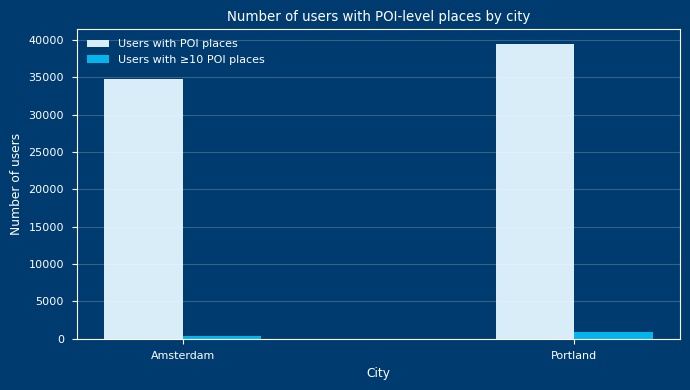

In [13]:
# number of users with POI level places for the three cities -- how it changes if we introduce a minimum of 10 places?
poi_users = (
    df2[df2["place_type"] == "poi"]
    .groupby(["city_bbox", "user_id"], as_index=False)
    .agg(
        poi_place_cnt=("place_id", "nunique")
    )
)

summary_poi_users = (
    poi_users
    .groupby("city_bbox", as_index=False)
    .agg(
        users_with_poi=("user_id", "nunique"),
        users_with_min10_poi=("poi_place_cnt", lambda x: (x >= 10).sum())
    )
)

city_order = ["amsterdam", "portland"]

plot_data = (
    summary_poi_users
    .set_index("city_bbox")
    .reindex(city_order)
    .fillna(0)
    .reset_index()
)

plt.style.use("seaborn-v0_8-paper")

x = np.arange(len(plot_data))
width = 0.2

fig, ax = plt.subplots(figsize=(7, 4))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

ax.bar(
    x - width/2,
    plot_data["users_with_poi"],
    width = 0.2,
    label="Users with POI places",
    color="#D8EDF7"
)

ax.bar(
    x + width/2,
    plot_data["users_with_min10_poi"],
    width = 0.2,
    label="Users with ≥10 POI places",
    color="#02b5ec"
)

ax.set_title("Number of users with POI-level places by city", color="white")
ax.set_xlabel("City", color="white")
ax.set_ylabel("Number of users", color="white")

ax.set_xticks(x)
ax.set_xticklabels(plot_data["city_bbox"].str.capitalize())

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

legend = ax.legend()
for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")

ax.grid(axis="y", color="white", alpha=0.2)
ax.grid(axis="x", visible=False)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Users visiting more than 5 POIs per year

* keep users with more than 5 POI-level places in a year
* count these users by city and year
* line chart of yearly user counts
* compare POI-based activity across cities over time

In [15]:
# how many users do we see visiting >5 POI in a year per city? / same for neighborhood 
df2["created_at"] = pd.to_datetime(df2["created_at"])
df2["years"] = df2["created_at"].dt.year

city_order = ["amsterdam", "portland"]
all_years = sorted(df2["years"].dropna().unique())

city_colors = {
    "london": "#D8EDF7",
    "amsterdam": "#02b5ec",
    "portland": "#092140"
}

poi_user_places = (
    df2[df2["place_type"] == "poi"]
    .groupby(["city_bbox", "years", "user_id"], as_index=False)
    .agg(place_cnt=("place_id", "nunique"))
)

poi_summary = (
    poi_user_places[poi_user_places["place_cnt"] > 5]
    .groupby(["city_bbox", "years"], as_index=False)
    .agg(user_cnt=("user_id", "nunique"))
)

poi_summary = (
    poi_summary
    .set_index(["city_bbox", "years"])
    .reindex(
        pd.MultiIndex.from_product(
            [city_order, all_years],
            names=["city_bbox", "years"]
        ),
        fill_value=0
    )
    .reset_index()
)

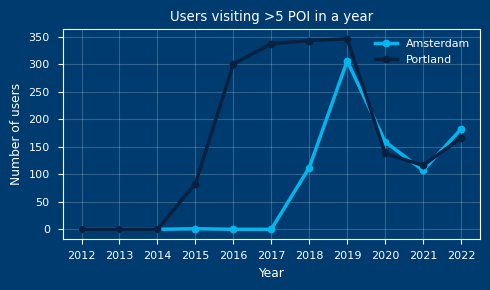

In [16]:
plt.style.use("seaborn-v0_8-paper")

fig, ax = plt.subplots(figsize=(5, 3))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

for city in city_order:
    one_city = poi_summary[poi_summary["city_bbox"] == city]

    ax.plot(
        one_city["years"],
        one_city["user_cnt"],
        marker="o",
        color=city_colors[city],
        linewidth=2.5,
        label=city.capitalize()
    )

ax.set_title("Users visiting >5 POI in a year", color="white")
ax.set_xlabel("Year", color="white")
ax.set_ylabel("Number of users", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.set_xticks(all_years)

legend = ax.legend()
for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")

ax.grid(color="white", alpha=0.2)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Users visiting more than 5 neighborhoods per year

* keep users with more than 5 neighborhood-level places in a year
* count these users by city and year
* compare neighborhood-level mobility across cities over time

In [18]:
# how many users do we see visiting >5 neighborhood in a year per city?
neighborhood_user_places = (
    df2[df2["place_type"] == "neighborhood"]
    .groupby(["city_bbox", "years", "user_id"], as_index=False)
    .agg(place_cnt=("place_id", "nunique"))
)

neighborhood_summary = (
    neighborhood_user_places[neighborhood_user_places["place_cnt"] > 5]
    .groupby(["city_bbox", "years"], as_index=False)
    .agg(user_cnt=("user_id", "nunique"))
)

neighborhood_summary = (
    neighborhood_summary
    .set_index(["city_bbox", "years"])
    .reindex(
        pd.MultiIndex.from_product(
            [city_order, all_years],
            names=["city_bbox", "years"]
        ),
        fill_value=0
    )
    .reset_index()
)

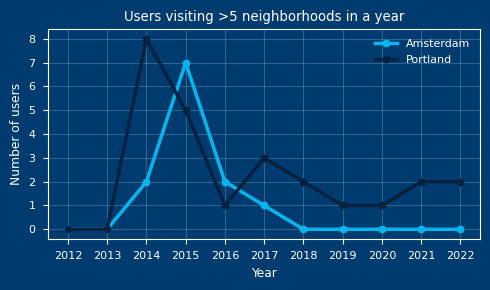

In [19]:
plt.style.use("seaborn-v0_8-paper")

fig, ax = plt.subplots(figsize=(5, 3))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

for city in city_order:
    one_city = neighborhood_summary[neighborhood_summary["city_bbox"] == city]

    ax.plot(
        one_city["years"],
        one_city["user_cnt"],
        marker="o",
        color=city_colors[city],
        linewidth=2.5,
        label=city.capitalize()
    )

ax.set_title("Users visiting >5 neighborhoods in a year", color="white")
ax.set_xlabel("Year", color="white")
ax.set_ylabel("Number of users", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.set_xticks(all_years)

legend = ax.legend()
for text in legend.get_texts():
    text.set_color("white")

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")

ax.grid(color="white", alpha=0.2)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Home-location share by city:

* keep only users with detected home location
* calculate total tweets per user
* count tweets inside the inferred home hexagon
* compute each user's home tweet share
* compare average and median home share by city

In [20]:
pd.read_sql("""
select city,
       count(user_id) users,
       avg(home_tweet::numeric / all_tweet) avg_home_share,
       percentile_cont(0.5) within group 
           (order by home_tweet::numeric / all_tweet) median_home_share
from (
    select city,
           user_id,
           count(tweet_id) all_tweet,
           count(case when homelocation_h3_10 = 'Y' then tweet_id end) home_tweet
    from homelocation
    group by city, user_id
    having count(case when homelocation_h3_10 = 'Y' then tweet_id end) > 0
) a
group by city;""",engine)

,city,users,avg_home_share,median_home_share
0,amsterdam,9993,0.276077,0.142857
1,london,160844,0.216444,0.076923
2,portland,16724,0.173014,0.084135


Home location detection success by city:

* count all users by city
* count users with detected home location
* calculate the share of users with home location
* calculate the share of users without home location
* show detection success as stacked bar chart
* use H3 resolution 10

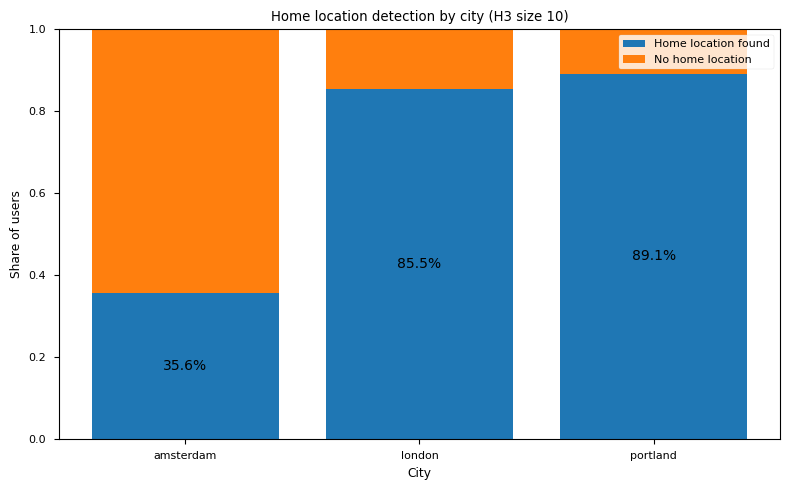

In [21]:
home_df = pd.read_sql("""
select city,
       count(distinct user_id) all_user,
       count(distinct case when homelocation_h3_10 = 'Y' then user_id end) homeloc_user,
       count(distinct case when homelocation_h3_10 = 'Y' then user_id end)::numeric /
       count(distinct user_id) as share_user
from homelocation
group by city
order by city
""", engine)


home_df["no_homeloc_share"] = 1 - home_df["share_user"]

plt.figure(figsize=(8, 5))

plt.bar(
    home_df["city"],
    home_df["share_user"],
    label="Home location found"
)

plt.bar(
    home_df["city"],
    home_df["no_homeloc_share"],
    bottom=home_df["share_user"],
    label="No home location"
)

for i, row in enumerate(home_df.itertuples()):
    plt.text(
        i,
        row.share_user / 2,
        f"{row.share_user:.1%}",
        ha="center",
        va="center"
    )

plt.ylabel("Share of users")
plt.xlabel("City")
plt.title("Home location detection by city (H3 size 10)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

Distribution of home-location share by city:

* calculate total tweets per user
* calculate tweets posted from the inferred home hexagon
* compute user-level home share
* plot home share distribution separately for each city
* compare how concentrated users' tweets are around home locations

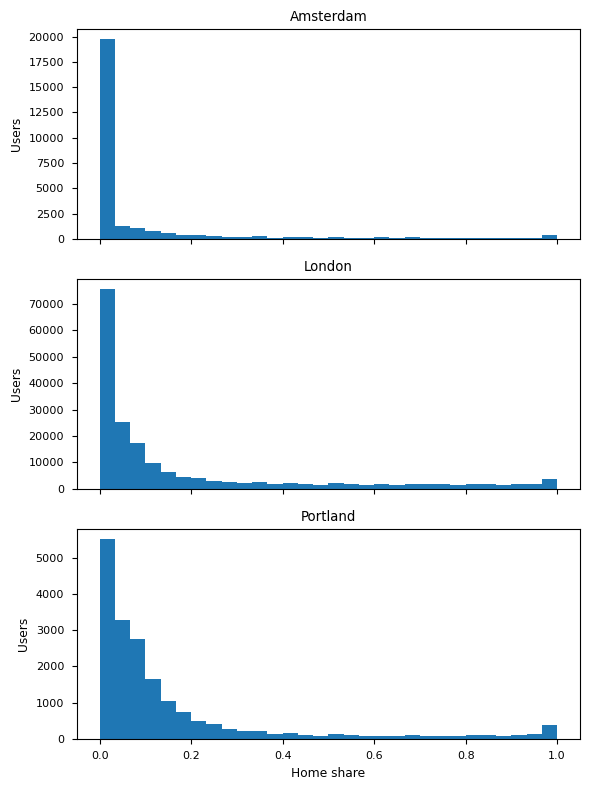

In [22]:
user_home_share = pd.read_sql("""
select city,
       user_id,
       count(tweet_id) as all_tweet,
       count(case when homelocation_h3_10 = 'Y' then tweet_id end) as home_tweet,
       count(case when homelocation_h3_10 = 'Y' then tweet_id end)::numeric
       / count(tweet_id) as home_share
from homelocation
group by city, user_id
""", engine)

# városonként mutatja a home share eloszlását
# a felhasználók tweetjeinek mekkora része származik a kijelölt home locationből
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

cities = ["amsterdam", "london", "portland"]

for ax, city in zip(axes, cities):

    subset = user_home_share[
        user_home_share["city"] == city
    ]

    ax.hist(
        subset["home_share"],
        bins=30
    )

    ax.set_title(city.capitalize())
    ax.set_ylabel("Users")

axes[-1].set_xlabel("Home share")

plt.tight_layout()
plt.show()

ECDF of user-level home share

* calculate the empirical cumulative distribution of home_share
* plot the distribution separately for each city
* compare how concentrated users’ tweets are around the inferred home location
* show the cumulative share of users below each home-share value
* use H3 resolution 10

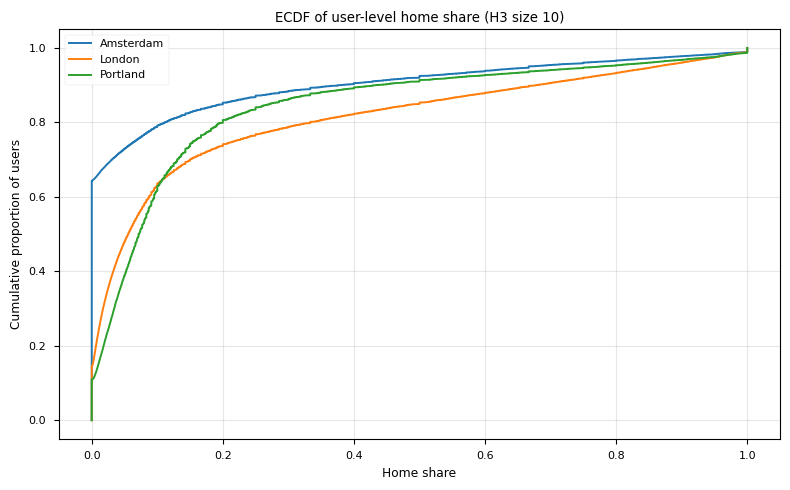

In [23]:
plt.figure(figsize=(8, 5))

for city in ["amsterdam", "london", "portland"]:

    subset = user_home_share.loc[
        user_home_share["city"] == city,
        "home_share"
    ].sort_values()

    y = np.arange(1, len(subset) + 1) / len(subset)

    plt.plot(
        subset,
        y,
        label=city.capitalize()
    )

plt.xlabel("Home share")
plt.ylabel("Cumulative proportion of users")
plt.title("ECDF of user-level home share (H3 size 10)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
#plt.xlim(0, 0.3)
plt.show()

Summary statistics of home share by city:

* calculate descriptive statistics of user-level home share
* group users by city
* report count, mean, standard deviation, quartiles and maximum
* compare home-location concentration across cities

In [24]:
user_home_share.groupby("city")["home_share"].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
amsterdam,28032.0,0.098417,0.219546,0.0,0.000000,0.000000,0.066667,1.0
london,188195.0,0.184987,0.271774,0.0,0.011494,0.055556,0.218182,1.0
portland,18779.0,0.154081,0.226248,0.0,0.026316,0.071429,0.156250,1.0
